# Análise de dados do dadaset

Análise dos dados obtidos através de vídeos públicos disponíveis no YouTube.
Informações e links de acesso disponíveis em : _./data/info.txt_

In [2]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np

In [3]:
path_car_dataset = "/dados/canela/alpr-dataset/output_dataset/cars_dataset.csv"
path_plates_dataset = "/dados/canela/alpr-dataset/output_dataset/plates_dataset.csv"
path_ocrs_dataset = "/dados/canela/alpr-dataset/output_dataset/ocrs_dataset.csv"

df_car_dataset = pd.read_csv(path_car_dataset)
df_plates_dataset = pd.read_csv(path_plates_dataset)
df_ocrs_dataset = pd.read_csv(path_ocrs_dataset)

### Dataset de carros coletados

In [4]:
print(f" car_dataset | shape {df_car_dataset.shape[0]}x{df_car_dataset.shape[1]}")
print(f" car_dataset | valores ausentes: \n {df_car_dataset.isna().sum()}")

 car_dataset | shape 374173x6
 car_dataset | valores ausentes: 
 id              0
id_font         0
bbox            0
label           0
conf            0
source_video    0
dtype: int64


In [5]:
display(df_car_dataset.head())
df_car_dataset.info()
#bbox relativo ao input do video

,id,id_font,bbox,label,conf,source_video
0,car_be143090,371,"(686, 283, 945, 371)",carro,0.911166,natal.webm
1,car_0cd651d7,484,"(105, 599, 455, 715)",carro,0.918776,natal.webm
2,car_fdf7b546,485,"(107, 598, 451, 714)",carro,0.941551,natal.webm
3,car_03ac1c04,486,"(109, 596, 456, 714)",carro,0.937566,natal.webm
4,car_e60df60f,489,"(126, 585, 483, 719)",carro,0.944151,natal.webm


<class 'pandas.DataFrame'>
RangeIndex: 374173 entries, 0 to 374172
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            374173 non-null  str    
 1   id_font       374173 non-null  int64  
 2   bbox          374173 non-null  str    
 3   label         374173 non-null  str    
 4   conf          374173 non-null  float64
 5   source_video  374173 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 17.1 MB


### Dataset de placas coletadas

In [6]:
print(f" car_dataset | shape {df_plates_dataset.shape[0]}x{df_plates_dataset.shape[1]}")
print(f" car_dataset | valores ausentes: \n {df_plates_dataset.isna().sum()}")

 car_dataset | shape 280773x6
 car_dataset | valores ausentes: 
 id              0
id_font         0
bbox            0
label           0
conf            0
source_video    0
dtype: int64


In [7]:
display(df_plates_dataset.head())
df_plates_dataset.info()
#bbox relativo ao input do video

,id,id_font,bbox,label,conf,source_video
0,plt_ee45daf8,car_5e1323c8,"(50, 426, 126, 489)",antiga,0.999593,natal.webm
1,plt_45e9155b,car_31b2e157,"(22, 437, 99, 499)",antiga,0.997985,natal.webm
2,plt_34c8b154,car_4ccda413,"(0, 433, 53, 494)",antiga,0.987310,natal.webm
3,plt_2bae226f,car_61d13843,"(386, 418, 476, 470)",nova,0.983743,natal.webm
4,plt_33bcd90b,car_b672a4e8,"(374, 452, 463, 513)",nova,0.985178,natal.webm


<class 'pandas.DataFrame'>
RangeIndex: 280773 entries, 0 to 280772
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            280773 non-null  str    
 1   id_font       280773 non-null  str    
 2   bbox          280773 non-null  str    
 3   label         280773 non-null  str    
 4   conf          280773 non-null  float64
 5   source_video  280773 non-null  str    
dtypes: float64(1), str(5)
memory usage: 12.9 MB


### Dataset de placas identificadas

In [8]:
print(f" car_dataset | shape {df_ocrs_dataset.shape[0]}x{df_ocrs_dataset.shape[1]}")
print(f" car_dataset | valores ausentes: \n {df_ocrs_dataset.isna().sum()}")

 car_dataset | shape 116466x6
 car_dataset | valores ausentes: 
 id              0
id_font         0
bbox            0
label           0
conf            0
source_video    0
dtype: int64


In [9]:
display(df_ocrs_dataset.head())
df_ocrs_dataset.info()
#bbox relativo ao input do video

,id,id_font,bbox,label,conf,source_video
0,ocr_42737f0c,plt_ef2f4c2b,"(317, 438, 452, 507)",DGV2273,0.986949,natal.webm
1,ocr_131a7624,plt_e1820d85,"(310, 434, 449, 502)",DGV2273,0.989926,natal.webm
2,ocr_a141c600,plt_12f4f638,"(317, 442, 453, 511)",OGV2273,0.997654,natal.webm
3,ocr_a4dfd0d2,plt_96237a80,"(319, 446, 457, 515)",OGV2273,0.999728,natal.webm
4,ocr_06037066,plt_3ae428e5,"(322, 446, 460, 518)",OGV2273,0.998313,natal.webm


<class 'pandas.DataFrame'>
RangeIndex: 116466 entries, 0 to 116465
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            116466 non-null  str    
 1   id_font       116466 non-null  str    
 2   bbox          116466 non-null  str    
 3   label         116466 non-null  str    
 4   conf          116466 non-null  float64
 5   source_video  116466 non-null  str    
dtypes: float64(1), str(5)
memory usage: 5.3 MB


In [10]:
#verifica a quantidade de placas unicas
total_placas = df_ocrs_dataset['label'].nunique()
_placas_count = df_ocrs_dataset['label'].value_counts()
media_placas_duplicadas = _placas_count.mean()
min_placas_duplicadas = _placas_count.min()
max_placas_duplicadas = _placas_count.max()

print(f"Placas unicas: {total_placas}")
print(f"Placas media de duplicadas: {media_placas_duplicadas}")
print(f"Placas minima de duplicadas: {min_placas_duplicadas}")
print(f"Placas maxima de duplicadas: {max_placas_duplicadas}")


Placas unicas: 1229
Placas media de duplicadas: 94.76484947111473
Placas minima de duplicadas: 1
Placas maxima de duplicadas: 10457


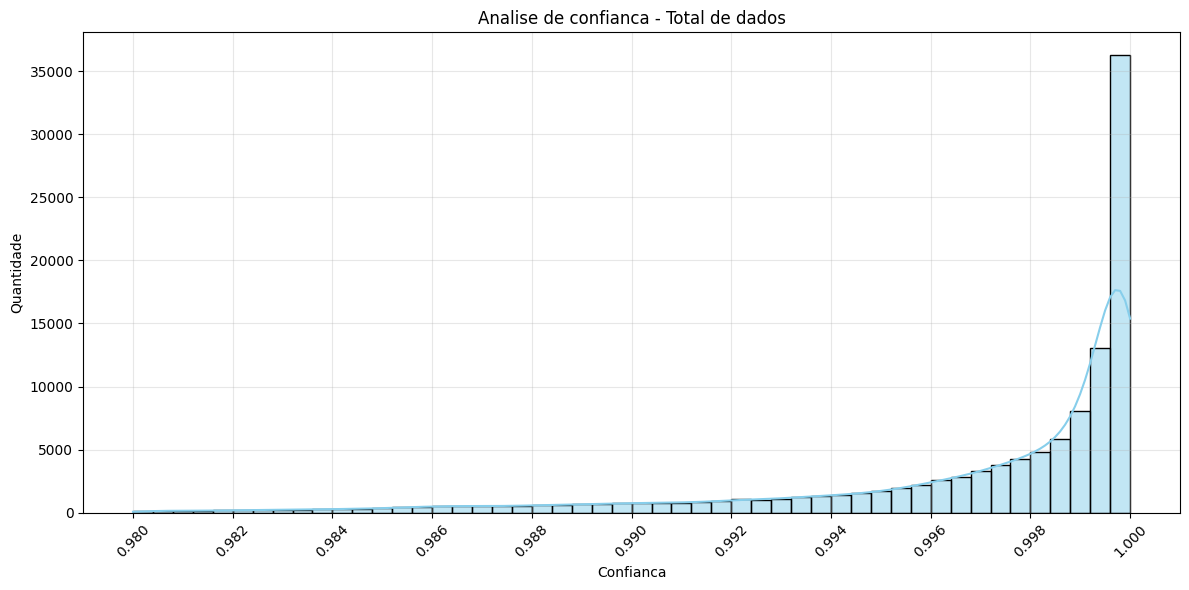

In [11]:
# Distribuicao de confianca total
plt.figure(figsize=(12, 6))

# Filtro maior que 0.98
data_filtro = df_ocrs_dataset[df_ocrs_dataset['conf'] >= 0.98]

sns.histplot(data_filtro['conf'], bins=50, kde=True, color='skyblue')

ticks = np.linspace(0.98, 1.00, 11)
plt.xticks(ticks, [f"{t:.3f}" for t in ticks], rotation=45)

plt.title('Analise de confianca - Total de dados')
plt.xlabel('Confianca')
plt.ylabel('Quantidade')
plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

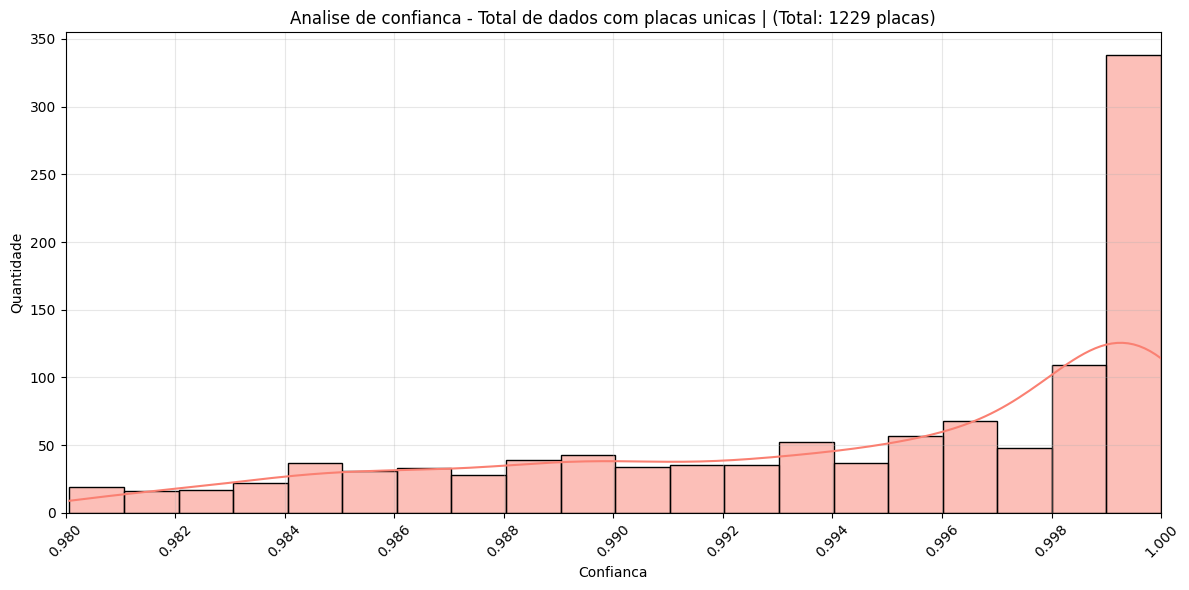

In [12]:
# Distribuicao de confianca total com dados unicos
plt.figure(figsize=(12, 6))

# Filtro placas unicas
df_labels_unicos = df_ocrs_dataset.sort_values('conf', ascending=False).drop_duplicates('label')
# Filtro maior que 0.98
data_filtro = df_labels_unicos[df_labels_unicos['conf'] >= 0.98]


sns.histplot(data_filtro['conf'], bins=20, kde=True, color='salmon')
plt.xlim(0.98, 1.00)
ticks = np.linspace(0.98, 1.00, 11)
plt.xticks(ticks, [f"{t:.3f}" for t in ticks], rotation=45)

plt.title(f'Analise de confianca - Total de dados com placas unicas | (Total: {len(df_labels_unicos)} placas)')
plt.xlabel('Confianca')
plt.ylabel('Quantidade')
plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

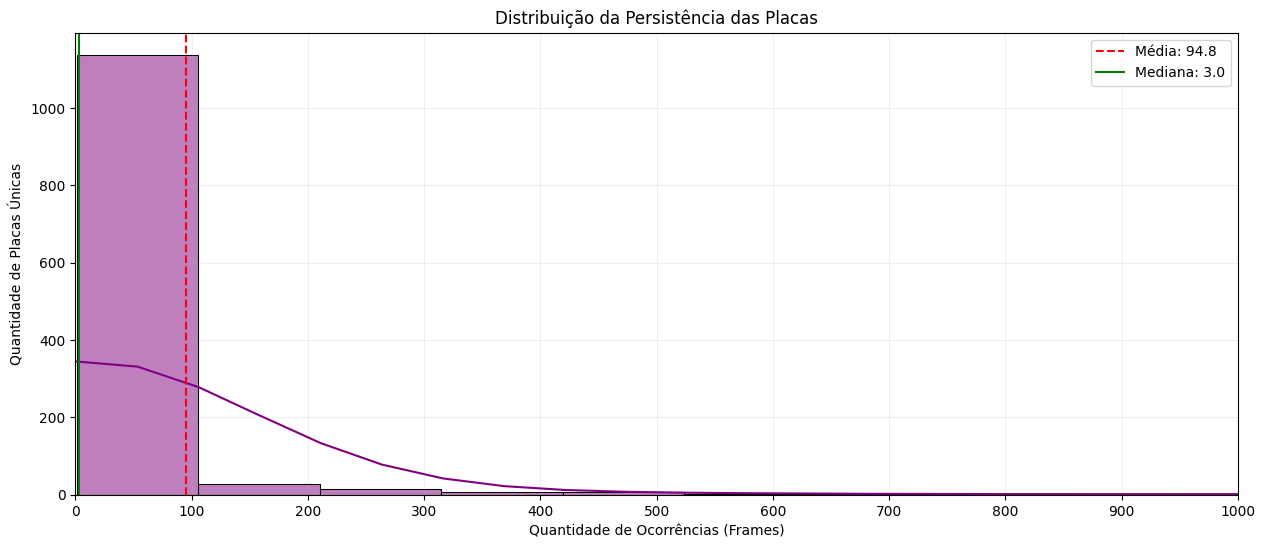

In [13]:
#Calculo da frequência (contagem de frames por placa)
contagem_placas = df_ocrs_dataset['label'].value_counts().reset_index()
contagem_placas.columns = ['label', 'frequencia']

plt.figure(figsize=(15, 6))

sns.histplot(contagem_placas['frequencia'], bins=100, kde=True, color='purple')
plt.xlim(0, 1000)
plt.xticks(np.arange(0, 1001, 100))

# 5. Linhas de referência (Média  Mediana)
media = contagem_placas['frequencia'].mean()
mediana = contagem_placas['frequencia'].median()
plt.axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.1f}')

plt.title('Distribuição da Persistência das Placas')
plt.xlabel('Quantidade de Ocorrências (Frames)')
plt.ylabel('Quantidade de Placas Únicas')
plt.legend()
plt.grid(axis='both', alpha=0.2)

plt.show()

In [15]:
# placas com conf entre 0.98 e 1.00
df_conf_filtrado = df_ocrs_dataset[(df_ocrs_dataset['conf'] >= 0.9) & (df_ocrs_dataset['conf'] <= 1.00)]

# ocorrencia de placas
contagem_por_label = df_conf_filtrado['label'].value_counts()

# filtra por quantidade de placas
labels_finais = contagem_por_label[(contagem_por_label >= 10) & (contagem_por_label <= 20000)]

print(f"Existem {len(labels_finais)} placas únicas que atendem aos dois critérios simultaneamente.")


Existem 385 placas únicas que atendem aos dois critérios simultaneamente.
